# "THE PRICE IS RIGHT" — Week 7, Day 2

## This week: fine-tune an open-source model with QLoRA

### Order of play
- DAY 1: QLoRA
- **DAY 2: Prompt Data and Base Model** ← *we are here*
- DAY 3: Train Part 1
- DAY 4: Train Part 2
- DAY 5: Eval

### Today — Prompt Data and Base Model

Before training we need to do two things:

1. **Decide the context-length cutoff.** Llama's SFTTrainer pads or truncates every example
   to a fixed `max_seq_length`. If we set it too small we lose information; too large and VRAM
   blows up. We'll count tokens in all our summaries and pick a cutoff that covers ≥ 99% of
   examples without truncation.

2. **Build prompt/completion pairs.** Instead of one big `prompt` string, SFT trainers expect
   the question part (`prompt`) and the answer part (`completion`) separately — so the loss is
   computed only on the completion tokens.

The result is a new HuggingFace dataset (`items_prompts_full` / `items_prompts_lite`) that
Days 3–4 will download directly inside Colab.

**Colab notebook for this day:**  
https://colab.research.google.com/drive/1wO3lNMrMfprlJZF4X9fSsQ8tYC3SRZbh?usp=sharing

### 💡 Why split prompt and completion?

During supervised fine-tuning the model sees the *full* sequence (prompt + completion) but
the loss is masked to cover only the completion tokens. This means:

- The model learns to *generate* the price, not just repeat the question.
- We don't waste gradient signal on the question text that is always the same.

`SFTTrainer` (from `trl`) handles the masking automatically when you pass
`dataset_text_field="prompt"` — but only if `prompt` already ends at the right boundary.
That's exactly how `Item.make_prompts()` builds it.

In [1]:
import os
import sys
from pathlib import Path

from dotenv import load_dotenv
from huggingface_hub import login
from tqdm.notebook import tqdm
from transformers import AutoTokenizer
import matplotlib.pyplot as plt

# Make the local `pricer` package importable no matter where the notebook is launched from.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    possible = candidate / "lectures" / "week-seven"
    if (possible / "pricer").exists():
        sys.path.insert(0, str(possible))
        break

from pricer.items import Item

load_dotenv(override=True)

True

In [2]:
LITE_MODE = False

hf_token = os.environ['HF_TOKEN']
login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


## Load the pre-processed dataset

This is the dataset we built in Week 6 Day 2 — products rewritten into a clean five-line
summary by an LLM. Each item has a `summary` field (the clean text) and a `price` (the target).

Set `username` to your own HuggingFace username to load your Week 6 output, or use
`"ed-donner"` to load the official pre-processed copy without having run Week 6 yourself.

In [3]:
username = "marcolerma"  # <-- your HuggingFace username, or "ed-donner" for the official copy
dataset = f"{username}/items_lite" if LITE_MODE else f"{username}/items_full"

train, val, test = Item.from_hub(dataset)
items = train + val + test

print(f"Loaded {len(train):,} training items, {len(val):,} validation items, {len(test):,} test items")

Loaded 800,000 training items, 10,000 validation items, 10,000 test items


## Load the base model tokenizer

We need the **same tokenizer** that will be used during training. Token counts vary by
tokenizer — Llama and GPT use different vocabularies — so always measure with the target model.

In [4]:
BASE_MODEL = "meta-llama/Llama-3.2-3B"

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)

config.json:   0%|          | 0.00/844 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

## Step 1 — Count tokens in each summary

Before building prompts we measure the token length of every `item.summary`. This tells us
how long the *input* part of each training example is, and guides our cutoff decision.

`Item.count_tokens()` calls `tokenizer.encode(self.summary, add_special_tokens=False)` and
returns the length — the `False` flag keeps us from inflating the count with BOS/EOS tokens.

In [5]:
token_counts = [item.count_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

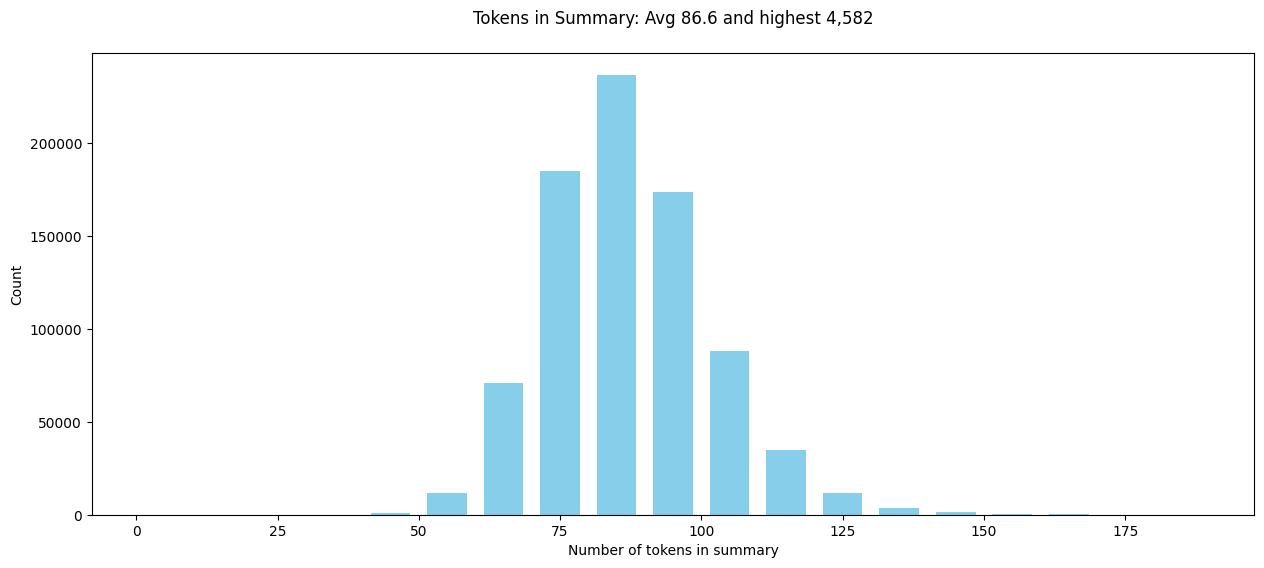

In [6]:
plt.figure(figsize=(15, 6))
plt.title(
    f"Tokens in Summary: Avg {sum(token_counts)/len(token_counts):,.1f} "
    f"and highest {max(token_counts):,}\n"
)
plt.xlabel('Number of tokens in summary')
plt.ylabel('Count')
plt.hist(token_counts, rwidth=0.7, color="skyblue", bins=range(0, 200, 10))
plt.show()

## Step 2 — Choose a truncation cutoff

The histogram should show most summaries clustered below 100 tokens (they're five short lines).
A `CUTOFF = 110` typically keeps over 99% of items intact. Check the percentage that would be
truncated at this value and adjust if needed.

In [7]:
CUTOFF = 110
cut = len([count for count in token_counts if count > CUTOFF])
print(f"With CUTOFF={CUTOFF}, we will truncate {cut:,} items which is {cut/len(items):.1%}")

With CUTOFF=110, we will truncate 47,083 items which is 5.7%


In [8]:
# Inspect what a summary looks like before building prompts
print(train[0].summary)

Title: Schlage F59 & 613 Andover Interior Knob (Deadbolt Included)  
Category: Home Hardware  
Brand: Schlage  
Description: A single‑piece oil‑rubbed bronze knob that mounts to a deadbolt for secure, easy interior door use.  
Details: Designed for a 4" minimum center‑to‑center door prep, it offers a lifetime mechanical and finish warranty and comes ready for quick installation.


## Step 3 — Build prompt/completion pairs

`Item.make_prompts(tokenizer, CUTOFF, include_price)` does three things:

1. Encodes the summary and truncates to `CUTOFF` tokens if needed.
2. Sets `item.prompt` = `"What does this cost…\n\n<summary>\n\nPrice is $"`
3. Sets `item.completion` = `"<rounded_price>.00"` (for train/val) or the raw price (for test).

For test items we pass `include_price=False` — the model must predict, not regurgitate.

In [9]:
for item in tqdm(train + val):
    item.make_prompts(tokenizer, CUTOFF, include_price=True)
for item in tqdm(test):
    item.make_prompts(tokenizer, CUTOFF, include_price=False)

  0%|          | 0/810000 [00:00<?, ?it/s]

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  0%|          | 0/10000 [00:00<?, ?it/s]

In [10]:
# Inspect a test item to confirm the prompt/completion split looks right
print("PROMPT:")
print(test[0].prompt)
print()
print("COMPLETION:")
print(test[0].completion)

PROMPT:
What does this cost to the nearest dollar?

Title: Excess V2 Distortion/Modulation Pedal  
Category: Music Pedals  
Brand: Old Blood Noise  
Description: A versatile pedal offering distortion and three modulation modes—delay, chorus, and harmonized fifths—with full control over signal routing and expression.  
Details: Features include separate gain, tone, and volume controls; time, depth, and volume per modulation; order switching, soft‑touch bypass, and expression jack for dynamic control.

Price is $

COMPLETION:
219.0


## Step 4 — Count tokens in the full prompt + completion

Now we measure the *total* token length of each training example (prompt + completion).
This is what actually dictates `max_seq_length` in the `SFTConfig`. The histogram should
show everything well below 150 tokens, giving us plenty of headroom.

In [11]:
prompt_token_counts = [item.count_prompt_tokens(tokenizer) for item in tqdm(items)]

  0%|          | 0/820000 [00:00<?, ?it/s]

In [ ]:
plt.figure(figsize=(15, 6))
plt.title(
    f"Tokens (prompt + completion): Avg {sum(prompt_token_counts)/len(prompt_token_counts):,.1f} "
    f"and highest {max(prompt_token_counts):,}\n"
)
plt.xlabel('Number of tokens in prompt and completion')
plt.ylabel('Count')
plt.hist(prompt_token_counts, rwidth=0.7, color="gold", bins=range(0, 200, 10))
plt.show()

## Step 5 — Push the prompt dataset to HuggingFace Hub

We push a leaner dataset containing only `prompt` and `completion` per item — the SFT trainer
doesn't need any of the other Item fields. Days 3–4 in Colab will `load_dataset()` from here.

Here are the official datasets for reference (handy if you want to skip this step):
- https://huggingface.co/datasets/ed-donner/items_prompts_lite
- https://huggingface.co/datasets/ed-donner/items_prompts_full

In [ ]:
username = "marcolerma"  # <-- your HuggingFace username
dataset = f"{username}/items_prompts_lite" if LITE_MODE else f"{username}/items_prompts_full"

Item.push_prompts_to_hub(dataset, train, val, test)

print(f"Pushed to: https://huggingface.co/datasets/{dataset}")

## What's next

The prompt dataset is now on the Hub and ready for the Colab training notebooks:

- **Day 3 (Train Part 1)** — set up the QLoRA config, load the dataset, run the first training epoch.
- **Day 4 (Train Part 2)** — push the fine-tuned adapter weights back to the Hub.
- **Day 5 (Eval)** — load the merged model locally and evaluate on the held-out test set.

The key number to note from this notebook: the **max prompt+completion token count** in the
histogram above. Set `max_seq_length` in the `SFTConfig` to that value (rounded up to the
nearest multiple of 8 for efficiency) when you open the Colab training notebook.